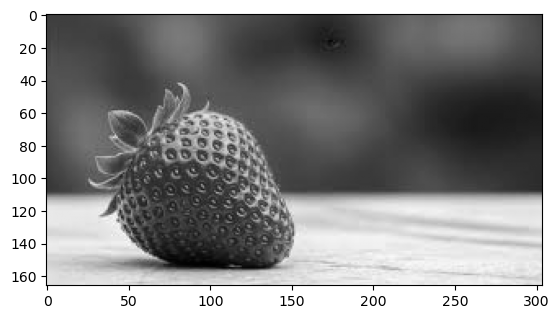

In [25]:
img1= cv2.imread('image1.jpeg')
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
rgbimg = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
plt.imshow(cv2.cvtColor(rgbimg, cv2.COLOR_RGB2GRAY), cmap='gray')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

img1= cv2.imread('image1.jpeg')
img2= cv2.imread('image2.jpeg')

height,width=img1.shape[:2] # to get height and width by excluding the feature chennel
img2=cv2.resize(img2,(width,height))

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB) # essential because cv2 read images in BGR format
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB) # thats why replacing BGR channels with RGB channels to view it properly using matplotlib
# use cv2.imshow("title", img) or use plt.imshow(img); plt.axis('off'); plt.show

def show_img(img, title):
    plt.imshow(img)
    plt.axis('off')
    plt.title(title)
    plt.show()

def show_subp_imgs(img1, title1, img2, title2):
    fig, axs=plt.subplots(1,2,figsize=(7,4))
    axs[0].imshow(img1)
    axs[0].set_title(title1)
    plt.axis('off')
    axs[1].imshow(img2)
    axs[1].set_title(title2)
    plt.axis('off')
    plt.show()

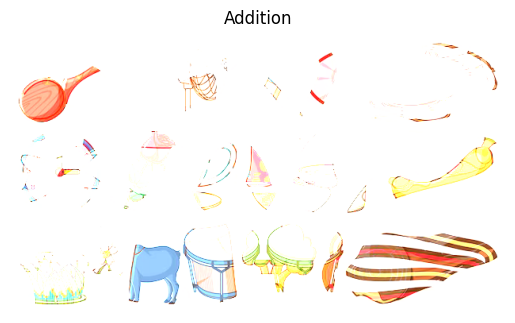

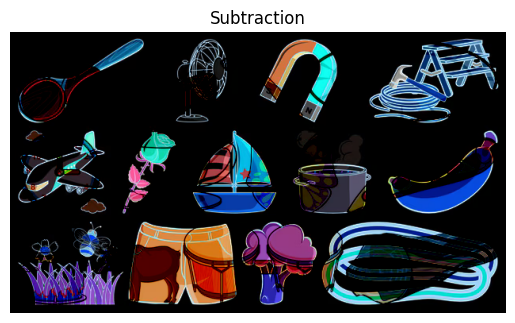

In [ ]:
# 01
# addition and subtraction of images

res=cv2.add(img1,img2)
show_img(res, "Addition")

res=cv2.subtract(img1, img2)
show_img(res, "Subtraction")

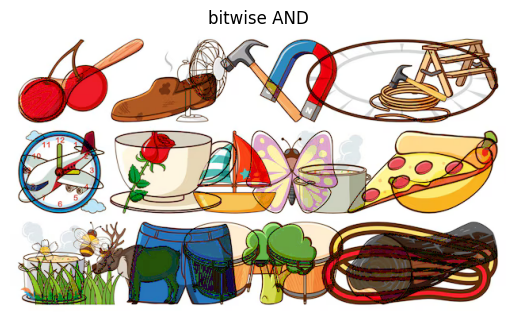

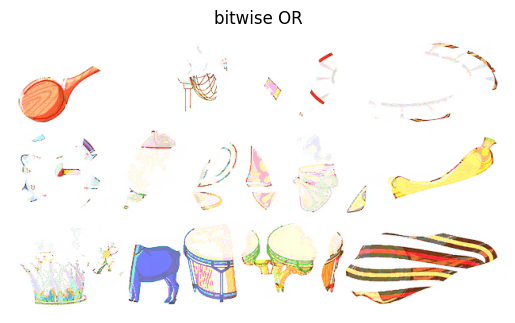

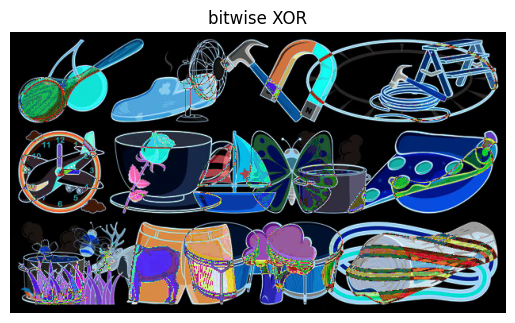

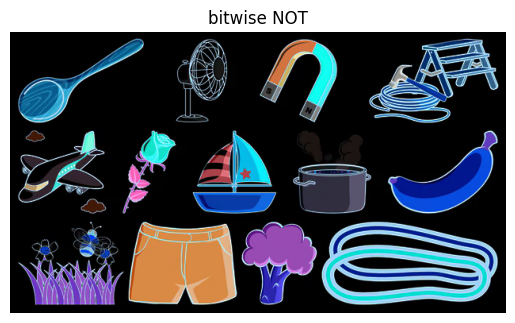

In [ ]:
# 02
# Bitwise OR, AND, NOT, XOR
res = cv2.bitwise_and(img2,img1,mask=None)
show_img(res, "bitwise AND")

res = cv2.bitwise_or(img2,img1,mask=None)
show_img(res, "bitwise OR")

res = cv2.bitwise_xor(img2,img1,mask=None)
show_img(res, "bitwise XOR")

res = cv2.bitwise_not(img2,mask=None)
show_img(res, "bitwise NOT")

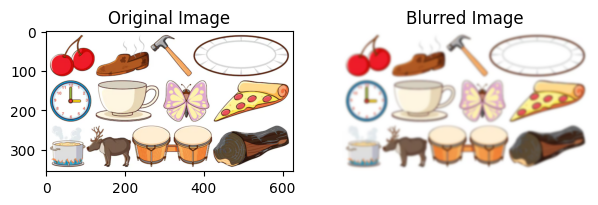

In [ ]:
# 03
# Reducing noise using image blurring

blurred_img=cv2.GaussianBlur(img1,(15, 15),0)
show_subp_imgs(img1, 'Original Image', blurred_img, 'Blurred Image')

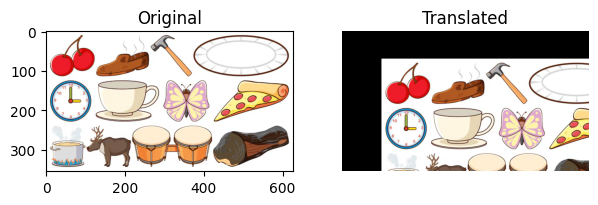

In [ ]:
# 04
# image translation

tx = 100
ty = 70

translation_matrix = np.array([[1, 0, tx], [0, 1, ty]], dtype=np.float32)
res = cv2.warpAffine(img1, translation_matrix, (img1.shape[1], img1.shape[0]))

show_subp_imgs(img1, "Original", res, "Translated")

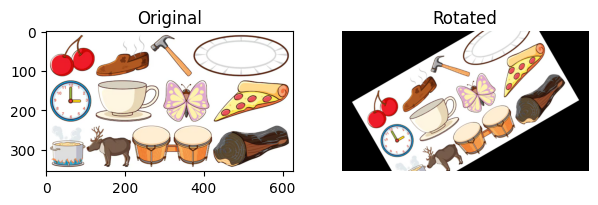

In [ ]:
# 05
# image rotation

center = img1.shape[1] // 2, img1.shape[0] // 2
angle = 30
scale = 0.8

rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)
res = cv2.warpAffine(img1, rotation_matrix,  (img1.shape[1], img1.shape[0]))

show_subp_imgs(img1, "Original", res, "Rotated")

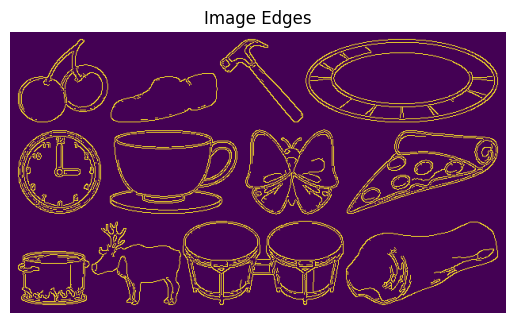

In [ ]:
# 06
# detecting edges in image

edg_img = cv2.Canny(img1, 100, 700)
show_img(edg_img, "Image Edges")

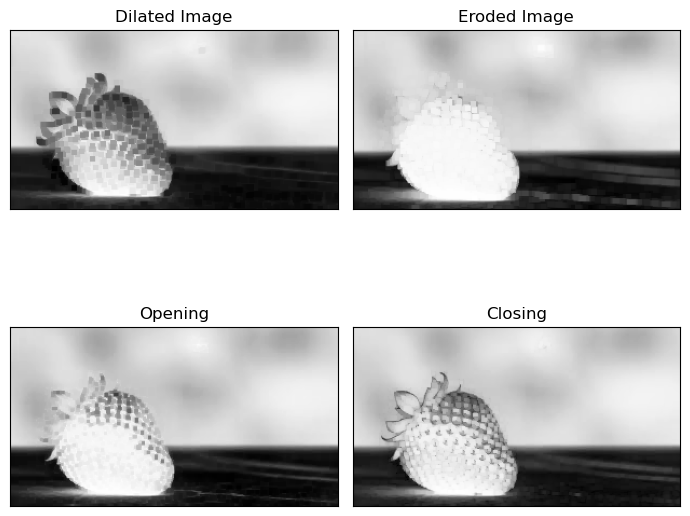

In [4]:
image_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY) 

# Create a structuring element
kernel = np.ones((3, 3), np.uint8)

# Perform dilation
dilated = cv2.dilate(image_gray, kernel, iterations=2)

# Perform erosion
eroded = cv2.erode(image_gray, kernel, iterations=2)

# Perform opening (erosion followed by dilation)
opening = cv2.morphologyEx(image_gray, cv2.MORPH_OPEN, kernel)

# Perform closing (dilation followed by erosion)
closing = cv2.morphologyEx(image_gray, cv2.MORPH_CLOSE, kernel)

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(7, 7))

# Plot the Dilated Image
axs[0, 0].imshow(dilated, cmap='Greys')
axs[0, 0].set_title('Dilated Image')
axs[0, 0].set_xticks([])
axs[0, 0].set_yticks([])

# Plot the Eroded Image
axs[0, 1].imshow(eroded, cmap='Greys')
axs[0, 1].set_title('Eroded Image')
axs[0, 1].set_xticks([])
axs[0, 1].set_yticks([])

# Plot the opening (erosion followed by dilation)
axs[1, 0].imshow(opening, cmap='Greys')
axs[1, 0].set_title('Opening')
axs[1, 0].set_xticks([])
axs[1, 0].set_yticks([])

# Plot the closing (dilation followed by erosion)
axs[1, 1].imshow(closing, cmap='Greys')
axs[1, 1].set_title('Closing')
axs[1, 1].set_xticks([])
axs[1, 1].set_yticks([])

# Display the subplots
plt.tight_layout()
plt.show()

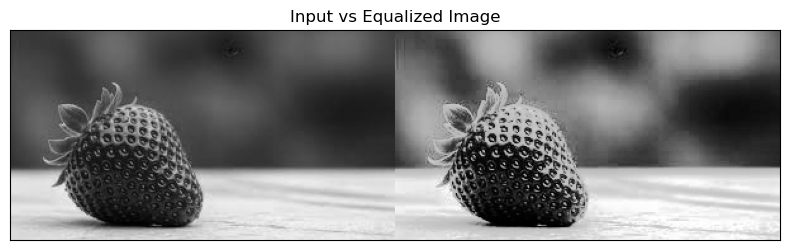

In [6]:
# creating a Histogram Equalization of an image using cv2.equalizeHist()
equ = cv2.equalizeHist(image_gray)

# stacking images side-by-side
res = np.hstack((image_gray, equ))

# show image input vs output using matplotlib
plt.figure(figsize=(8, 4))
plt.imshow(res, cmap='gray')
plt.title('Input vs Equalized Image')
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

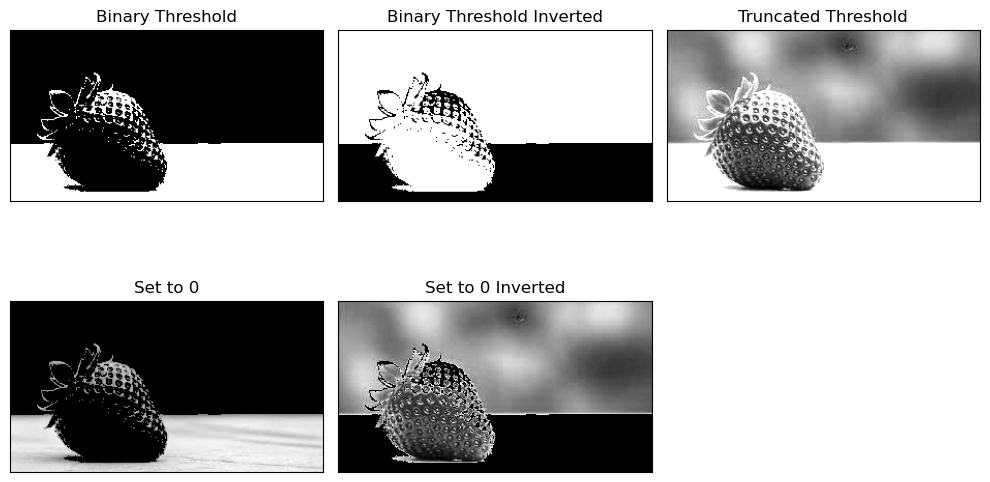

In [ ]:
# applying different thresholding techniques on the input image
# all pixels value above 120 will be set to 255
ret, thresh1 = cv2.threshold(image_gray, 120, 255, cv2.THRESH_BINARY)
ret, thresh2 = cv2.threshold(image_gray, 120, 255, cv2.THRESH_BINARY_INV)
ret, thresh3 = cv2.threshold(image_gray, 120, 255, cv2.THRESH_TRUNC)
ret, thresh4 = cv2.threshold(image_gray, 120, 255, cv2.THRESH_TOZERO)
ret, thresh5 = cv2.threshold(image_gray, 120, 255, cv2.THRESH_TOZERO_INV)

# show images using matplotlib
plt.figure(figsize=(10, 6))

plt.subplot(2, 3, 1)
plt.imshow(thresh1, cmap='gray')
plt.title('Binary Threshold')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 3, 2)
plt.imshow(thresh2, cmap='gray')
plt.title('Binary Threshold Inverted')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 3, 3)
plt.imshow(thresh3, cmap='gray')
plt.title('Truncated Threshold')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 3, 4)
plt.imshow(thresh4, cmap='gray')
plt.title('Set to 0')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 3, 5)
plt.imshow(thresh5, cmap='gray')
plt.title('Set to 0 Inverted')
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

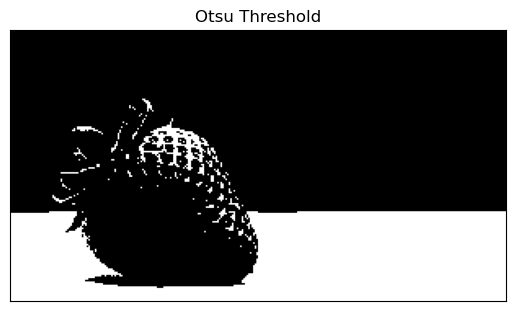

In [12]:
ret, thresh1 = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(thresh1, cmap='gray')
plt.title('Otsu Threshold')
plt.xticks([])
plt.yticks([])

plt.show()

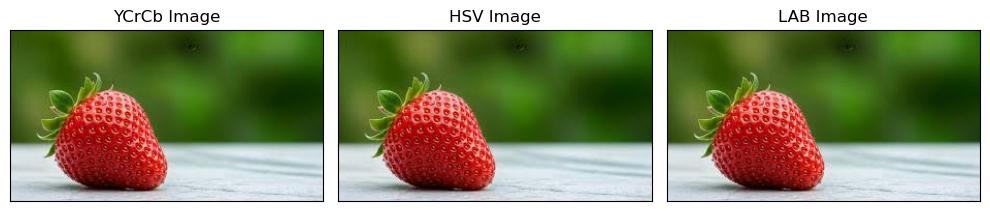

In [13]:

# Reads the image
img = cv2.imread('image1.jpeg')

# Convert to YCrCb color space
imgYC = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)

# Convert to HSV color space
imgHSV = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Convert to LAB color space
imgLAB = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

# Convert BGR to RGB for displaying with matplotlib
imgYC_rgb = cv2.cvtColor(imgYC, cv2.COLOR_YCrCb2RGB)
imgHSV_rgb = cv2.cvtColor(imgHSV, cv2.COLOR_HSV2RGB)
imgLAB_rgb = cv2.cvtColor(imgLAB, cv2.COLOR_LAB2RGB)

# Show images using matplotlib
plt.figure(figsize=(10, 6))

plt.subplot(1, 3, 1)
plt.imshow(imgYC_rgb)
plt.title('YCrCb Image')
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow(imgHSV_rgb)
plt.title('HSV Image')
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow(imgLAB_rgb)
plt.title('LAB Image')
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

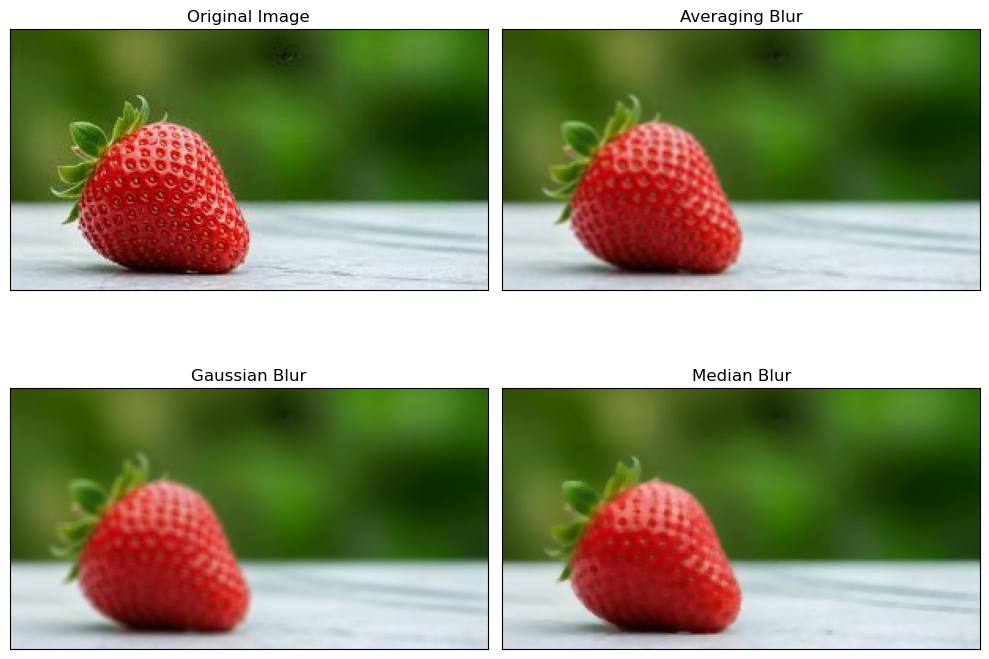

In [27]:
img1 = cv2.imread('image1.jpeg')

# Averaging the image
blrimg = cv2.blur(img1, (3, 3))

# Gaussian Blur
guassimg = cv2.GaussianBlur(img1, (5, 5), cv2.BORDER_DEFAULT)

# Median blur
medimg = cv2.medianBlur(img1, 5)

# Show all images in subplots
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(blrimg, cv2.COLOR_BGR2RGB))
plt.title('Averaging Blur')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(guassimg, cv2.COLOR_BGR2RGB))
plt.title('Gaussian Blur')
plt.xticks([])
plt.yticks([])

plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(medimg, cv2.COLOR_BGR2RGB))
plt.title('Median Blur')
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()